# 02 - Exploratory Data Analysis

Descriptive EDA on the validated dataset, **before any splitting or training**: document
count, class counts/percentages and imbalance, missing/empty text, duplicate count,
text-length distribution (mean/median/max/95th percentile), text-length histogram and
boxplot, and representative TF-IDF terms per agency.

EDA may guide preprocessing and training choices (the long-document strategy, whether
weighted loss is needed) but must never use test-set performance to tune anything -- it only
ever runs on the full, unsplit dataset.

All computation lives in `src/newstart_ai/eda/`; this notebook only calls it and displays
results.

### Load configuration and the dataset again

**Purpose:** Load the same configuration and dataset used in notebook 01, plus the `eda`
module that contains all the plotting and summary functions used throughout this notebook.

**Why this step is necessary:** Each notebook is a self-contained, re-runnable unit that
loads its own inputs rather than depending on in-memory state from a previous notebook. EDA
happens on the *full*, unsplit dataset -- deliberately before the train/validation/test
split in notebook 03, so none of these observations can accidentally leak information about
which rows will later become the test set.

**Inputs:** `configs/base.yaml` (via `settings`) and `data/processed/final_dataset.csv`.

**Output:** `settings`, `df` (754 rows), and the imported `eda` module.

**How to interpret the result:** Just a confirmation that the same 754 documents from
notebook 01 loaded successfully; the real analysis starts in the next cell.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..") / "src"))

from newstart_ai.config import load_settings
from newstart_ai.data.validation import load_dataset
from newstart_ai import eda

# Deliberately load the FULL dataset here, not a split -- EDA must happen before splitting
# so no decision made here can be influenced by knowledge of which rows end up in test.csv.
settings = load_settings()
df = load_dataset(settings)
print(f"{len(df)} documents loaded.")

754 documents loaded.


## Class counts and imbalance

### Class distribution

**Purpose:** Compute the exact document count and percentage share for each of the four
agencies.

**Why this step is necessary:** This is the first concrete look at class balance, which
directly informs two later decisions: whether BERT training needs class-weighted loss
(next cell), and how much weight to put on IRS's results given how few documents it has.

**Inputs:** `df` (the full dataset) and `settings` (for the label column name).

**Output:** `dist`, a small DataFrame with one row per agency.

**How to interpret the result:** DMV and USCIS should be the largest classes, SSA smaller,
and IRS by far the smallest (this is the same imbalance already seen in notebook 01 -- EDA
here just presents it visually and feeds the next cell's ratio calculation).

In [2]:
dist = eda.class_distribution(df, settings)
dist

,label,count,percentage
0,DMV,277,36.74
1,USCIS,256,33.95
2,SSA,198,26.26
3,IRS,23,3.05


### Quantify the imbalance and its practical consequence

**Purpose:** Compute the ratio between the largest and smallest class, and state in plain
language what that ratio means for BERT training.

**Why this step is necessary:** A ratio by itself is just a number; connecting it explicitly
to the configured `weighted_loss_threshold` (from `configs/bert.yaml`) makes clear *why* the
BERT training notebook (04) will apply class-weighted cross-entropy rather than training on
the raw class frequencies. This is a deliberate, documented modeling decision, not an
automatic default.

**Inputs:** `dist` (computed above) and `settings.bert.imbalance.weighted_loss_threshold`.

**Output:** Printed text -- no new object.

**How to interpret the result:** If the printed ratio is above the threshold (it is, at
roughly 12x), weighted loss will activate automatically during training; if it were below
the threshold, BERT would train with ordinary unweighted cross-entropy instead.

In [3]:
imbalance_ratio = dist['count'].max() / dist['count'].min()
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.1f}x")
print(
    "This exceeds the configured weighted-loss threshold "
    f"({settings.bert.imbalance.weighted_loss_threshold}x), so BERT training will use "
    "class-weighted cross-entropy (weights computed from the training split only)."
)

Imbalance ratio (majority/minority): 12.0x
This exceeds the configured weighted-loss threshold (4.0x), so BERT training will use class-weighted cross-entropy (weights computed from the training split only).


### Visualize the class distribution

**Purpose:** Render the class counts from `dist` as a bar chart.

**Why this step is necessary:** A chart makes the imbalance immediately legible to a human
reader in a way a table of numbers doesn't -- useful both for this notebook and for the
research summary and Research Results page that reuse EDA findings later.

**Inputs:** `df` and `settings`.

**Output:** A Matplotlib bar chart (rendered inline, not saved to disk from this cell).

**How to interpret the result:** The visual gap between IRS and the other three bars is the
same imbalance already quantified above -- seeing it as a chart is what makes it easy to
communicate in a written report.

<Axes: title={'center': 'Class distribution'}, xlabel='Agency', ylabel='Document count'>

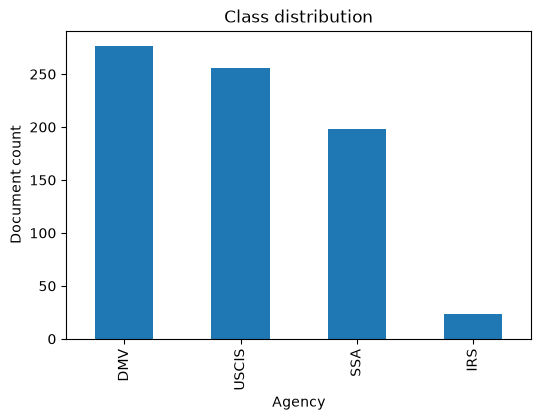

In [4]:
eda.plot_class_distribution(df, settings)

## Missing values

### Check for missing values in every column

**Purpose:** Report how many values are missing in each column of the raw dataset, not just
the `text` and `agency` columns used for classification.

**Why this step is necessary:** Even though notebook 01 already confirmed there's no missing
or empty `text`, other columns (like `form_number`) may still have gaps. Checking all
columns here is a broader data-quality sanity check than the validator's narrower,
classification-focused checks.

**Inputs:** `df` and `settings`.

**Output:** A DataFrame listing missing-value counts and percentages per column.

**How to interpret the result:** Missing values in metadata columns (e.g. `form_number`) are
expected and harmless for this project, since only `text` and `agency` are actually used for
modeling; missing values in `text` or `agency` would be a serious problem already ruled out
in notebook 01.

In [5]:
eda.missing_value_summary(df, settings)

,column,missing_count,missing_percentage
0,url,731,96.95
1,form_number,302,40.05
2,document_id,0,0.00
3,filename,0,0.00
4,agency,0,0.00
5,filepath,0,0.00
6,document_type,0,0.00
7,file_exists,0,0.00
8,text,0,0.00
9,page_count,0,0.00


## Text length

### Text length summary statistics

**Purpose:** Recompute the same length statistics shown in notebook 01 (mean, median, min,
max, 95th percentile), here as the anchor for the plots and long-document discussion that
follow.

**Why this step is necessary:** These numbers are the quantitative basis for the
long-document strategy comparison in notebook 04 -- the gap between the median and the
maximum length is what makes a naive fixed-length truncation risky for this dataset.

**Inputs:** `df` and `settings`.

**Output:** A dictionary of length statistics (in characters, not tokens).

**How to interpret the result:** A median in the thousands of characters with a maximum in
the hundreds of thousands confirms that some documents are dramatically longer than others
-- the plots below make this shape visible rather than just numeric.

In [6]:
eda.text_length_summary(df, settings)

{'mean': 15312.241379310344,
 'median': 7739.0,
 'minimum': 114,
 'maximum': 639219,
 'p95': 46745.85000000008}

### Text length histogram

**Purpose:** Plot the distribution of document lengths across the whole dataset.

**Why this step is necessary:** A histogram reveals the *shape* of the length distribution
(e.g. a long right tail of a few very long documents) in a way that summary statistics
alone cannot -- this shape is exactly why the project supports more than one long-document
strategy for BERT.

**Inputs:** `df` and `settings`.

**Output:** A Matplotlib histogram (rendered inline).

**How to interpret the result:** Expect most documents clustered at shorter lengths with a
small number of extreme outliers stretching the x-axis -- those outliers are inspected
individually a few cells below.

<Axes: title={'center': 'Text length distribution'}, xlabel='Character length', ylabel='Document count'>

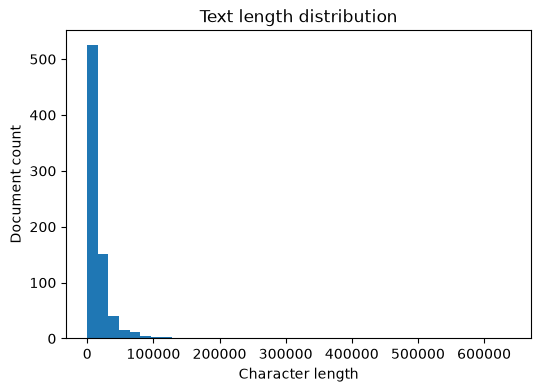

In [7]:
eda.plot_length_histogram(df, settings)

### Text length boxplot by agency

**Purpose:** Compare the length distribution separately for each of the four agencies.

**Why this step is necessary:** Document length may vary systematically by agency (e.g. tax
instructions tend to be long, forms tend to be short) -- this is worth knowing before
training, since it could interact with class imbalance in ways a single overall histogram
would hide.

**Inputs:** `df` and `settings`.

**Output:** A Matplotlib boxplot, one box per agency.

**How to interpret the result:** Wide boxes or many outlier points for a given agency mean
that agency's documents vary a lot in length; this is descriptive context, not something
this notebook acts on directly.

<Axes: title={'center': 'Text length by agency'}, ylabel='Character length'>

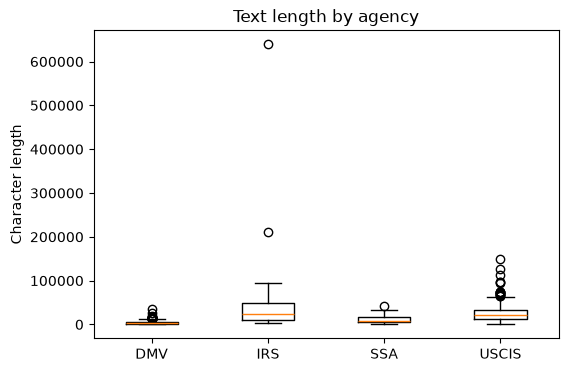

In [8]:
eda.plot_length_boxplot(df, settings)

## Longest documents

Extreme lengths must be inspected, not silently truncated: a legitimate long document gets
the configured long-document strategy; an extraction artifact (merged pages, duplicated
headers/footers, OCR noise) gets fixed upstream in `00_data_acquisition` as a new documented
dataset version.

### List the longest individual documents

**Purpose:** Show the specific documents with the most extreme character counts, along with
their agency label.

**Why this step is necessary:** Per the project's data-quality policy, an extremely long
document must be manually judged as either a *legitimate* long document (handled by the
configured long-document strategy) or an *upstream extraction problem* (duplicated pages,
merged documents, OCR noise) that should be fixed in `00_data_acquisition`, not silently
truncated or worked around here.

**Inputs:** `df` and `settings`.

**Output:** A DataFrame of the top 10 longest documents by character count, with their
`document_id` and `agency`.

**How to interpret the result:** See the note directly below this cell's output -- the two
longest documents here are both IRS and are called out explicitly as needing a manual
spot-check, not a code fix.

In [9]:
eda.longest_documents(df, settings, top_n=10)

,document_id,agency,text_length
0,739,IRS,639219
1,737,IRS,211174
2,191,USCIS,150025
3,30,USCIS,126257
4,83,USCIS,112399
5,202,USCIS,97284
6,113,USCIS,96145
7,86,USCIS,95550
8,736,IRS,94317
9,743,IRS,85528


The two longest records are IRS documents at 639,219 and 211,174 characters -- both far
above the 95th percentile (~46.7k). These should be spot-checked against their source PDFs
(`data/raw/irs/`) before assuming they are legitimate long-form guidance rather than a
concatenation/extraction artifact. This notebook does not modify them -- it only flags them
for upstream review.

## Representative TF-IDF terms per agency

### Representative TF-IDF terms per agency

**Purpose:** For each agency, list the words/phrases that a TF-IDF vectorizer weights most
highly for that class -- an approximation of the vocabulary that most distinguishes it from
the others.

**Why this step is necessary:** This is a lightweight, purely descriptive sanity check that
the four classes are lexically distinguishable at all *before* any model is trained. If the
top terms overlapped heavily across agencies, that would be an early warning sign that even
a well-tuned classifier might struggle; if they're clearly distinct (as seen below), it's a
reasonable expectation that a text classifier can do well on this task.

**Inputs:** `df` and `settings`.

**Output:** A dictionary mapping each agency label to its list of top TF-IDF terms.

**How to interpret the result:** Look for each agency's terms to reflect real, distinctive
subject matter for that agency; heavy overlap between two agencies would be a signal to
investigate the data further, not something this project encountered here.

In [10]:
keywords = eda.top_tfidf_terms_per_class(df, settings, top_n=12)
for label, terms in keywords.items():
    print(f"{label}: {', '.join(terms)}")

DMV: vehicle, dmv, california, number, license, driver, state, code, date, dl, section, motor
IRS: tax, irs, line, form, return, taxpayer, income, 1040, enter, installment, payments, instructions
SSA: ssa, social, information, social security, security, la, yes, act, form, form ssa, programs, benefits
USCIS: uscis, information, number, form, item, item number, application, provide, petition, interpreter, states, united


Each agency's top terms are clearly distinct (e.g. DMV -> vehicle/license/driver,
IRS -> tax/return/1040, SSA -> social security, USCIS -> application/form/item number),
which is a good descriptive sign that the classification task is learnable from text alone.

## Summary for the next notebook

- Dataset is confirmed imbalanced (~12x); class-weighted loss will be used for BERT.
- Two IRS documents are extreme outliers in length and should be spot-checked upstream.
- Classes are lexically distinguishable per TF-IDF, supporting the premise of the research
  question.
- No changes are made to the dataset here -- `03_reproducible_splitting.ipynb` operates on
  the same `final_dataset.csv` used above.